In [21]:
%load_ext autoreload
%autoreload 2
#%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import experiment.ocean.helpers as mod
import cyl_lvm as clvm
from scipy import stats

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [22]:
PROJECT_ROOT = mod.find_project_root()
DATA_DIR = PROJECT_ROOT / "data" / "ndbc"
DATA_PATH = DATA_DIR / "ocean_data.csv"

prepared = mod.prepare_data(csv_path=DATA_PATH, shuffle=True, random_state=157)

In [23]:
df = prepared["frame"]
train_frame = prepared["train_frame"]
test_frame = prepared["test_frame"]
x_train = prepared["x_train"]
x_train_lin, x_train_dir = x_train[:, :3], x_train[:, 3:]
x_test = prepared["x_test"]
x_test_lin, x_test_dir = x_test[:, :3], x_test[:, 3:]

split_summary = pd.DataFrame([
    {
        "split": "train",
        "n": len(train_frame),
        "start": prepared["train_time_range"][0],
        "end": prepared["train_time_range"][1],
    },
    {
        "split": "test",
        "n": len(test_frame),
        "start": prepared["test_time_range"][0],
        "end": prepared["test_time_range"][1],
    },
])
split_summary

,split,n,start,end
0,train,128420,2000-01-01 00:00:00+00:00,2021-05-25 18:50:00+00:00
1,test,32105,2000-01-01 02:00:00+00:00,2019-11-09 15:50:00+00:00


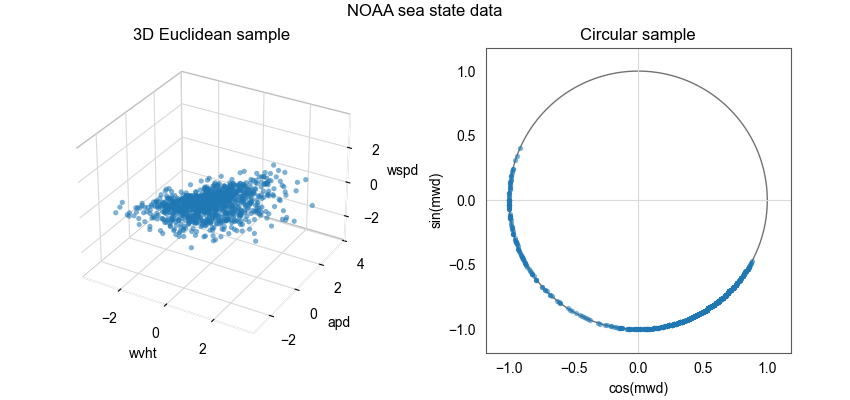

In [27]:
fig, axes = mod.plot_gaussian_vmf_sample(x_train,
                                         max_points=1000,
                                         figsize=(8.5, 4),
                                         show=True,
                                         title="NOAA sea state data",
                                         save_path="noaa_scatter.pdf")

In [5]:
feature_names = [*prepared["linear_features"], prepared["direction_feature"]]
model_feature_names = list(prepared["feature_names"])
feature_names

['wvht', 'apd', 'wspd', 'mwd']

In [6]:
x_train.shape, x_test.shape

((128420, 5), (32105, 5))

In [7]:
prepared["transformer"].lambdas_

array([-0.57773037, -0.3084441 ,  0.55105124])

### Training

In [8]:
settings = {'Independent cylindrical Mixture (Elbow)': [3],
            'Independent cylindrical Mixture (Grid)': [6],
            'Cylindrical Mixture (Elbow)': [3],
            'Cylindrical Mixture (Grid)': [6],
            'Gaussian/von Mises MoM (Elbow)': [3, 2],
            'Gaussian/von Mises MoM (Grid)': [6, 4],
            'Von Mises/Gaussian MoM (Elbow)': [3, 2],
            'Von Mises/Gaussian MoM (Grid)': [6, 4]
            }


In [9]:
indcyl_elbow = mod.ind_cylindrical_mixture_builder(
    d_gauss=3,
    d_vmf=2,
    n_components=settings['Independent cylindrical Mixture (Elbow)'][0],
    init="k-means",
    rng=57)
_ = indcyl_elbow.fit(x_train)

indcyl_grid = mod.ind_cylindrical_mixture_builder(
    d_gauss=3,
    d_vmf=2,
    n_components=settings['Independent cylindrical Mixture (Grid)'][0],
    init="k-means",
    rng=57)
_ = indcyl_grid.fit(x_train)

In [10]:
cyl_elbow = mod.cylindrical_mixture_builder(
    d_gauss=3,
    d_vmf=2,
    n_components=settings['Cylindrical Mixture (Elbow)'][0],
    init="k-means",
    rng=57)
_ = cyl_elbow.fit(x_train)

cyl_grid = mod.cylindrical_mixture_builder(
    d_gauss=3,
    d_vmf=2,
    n_components=settings['Cylindrical Mixture (Grid)'][0],
    init="k-means",
    rng=57)
_ = cyl_grid.fit(x_train)

In [11]:
tl_gauss_elbow = mod.two_layer_gaussian_vmf_builder(
    d_gauss=3,
    d_vmf=2,
    n_layer1_components=settings['Gaussian/von Mises MoM (Elbow)'][0],
    n_layer2_components=settings['Gaussian/von Mises MoM (Elbow)'][1],
    init_layer1="k-means",
    init_layer2="k-means",
    rng=57)
_ = tl_gauss_elbow.fit(x_train_lin, x_train_dir)

tl_gauss_grid = mod.two_layer_gaussian_vmf_builder(
    d_gauss=3,
    d_vmf=2,
    n_layer1_components=settings['Gaussian/von Mises MoM (Grid)'][0],
    n_layer2_components=settings['Gaussian/von Mises MoM (Grid)'][1],
    init_layer1="k-means",
    init_layer2="k-means",
    rng=57)
_ = tl_gauss_grid.fit(x_train_lin, x_train_dir)

In [12]:
tl_vmf_elbow = mod.two_layer_vmf_gaussian_builder(
    d_gauss=3,
    d_vmf=2,
    n_layer1_components=settings['Von Mises/Gaussian MoM (Elbow)'][0],
    n_layer2_components=settings['Von Mises/Gaussian MoM (Elbow)'][1],
    init_layer1="k-means",
    init_layer2="k-means",
    rng=57)
_ = tl_vmf_elbow.fit(x_train_dir, x_train_lin)

tl_vmf_grid = mod.two_layer_vmf_gaussian_builder(
    d_gauss=3,
    d_vmf=2,
    n_layer1_components=settings['Von Mises/Gaussian MoM (Grid)'][0],
    n_layer2_components=settings['Von Mises/Gaussian MoM (Grid)'][1],
    init_layer1="k-means",
    init_layer2="k-means",
    rng=57)
_ = tl_vmf_grid.fit(x_train_dir, x_train_lin)

In [13]:
models = {'cylindrical': {'Independent cylindrical Mixture (Elbow)': indcyl_elbow,
                          'Independent cylindrical Mixture (Grid)': indcyl_grid,
                          'Cylindrical Mixture (Elbow)': cyl_elbow,
                          'Cylindrical Mixture (Grid)': cyl_grid},
          'two-layer-gauss': {'Gaussian/von Mises MoM (Elbow)': tl_gauss_elbow,
                              'Gaussian/von Mises MoM (Grid)': tl_gauss_grid},
          'two-layer-vmf': {'Von Mises/Gaussian MoM (Elbow)': tl_vmf_elbow,
                            'Von Mises/Gaussian MoM (Grid)': tl_vmf_grid}
          }

### Visualization

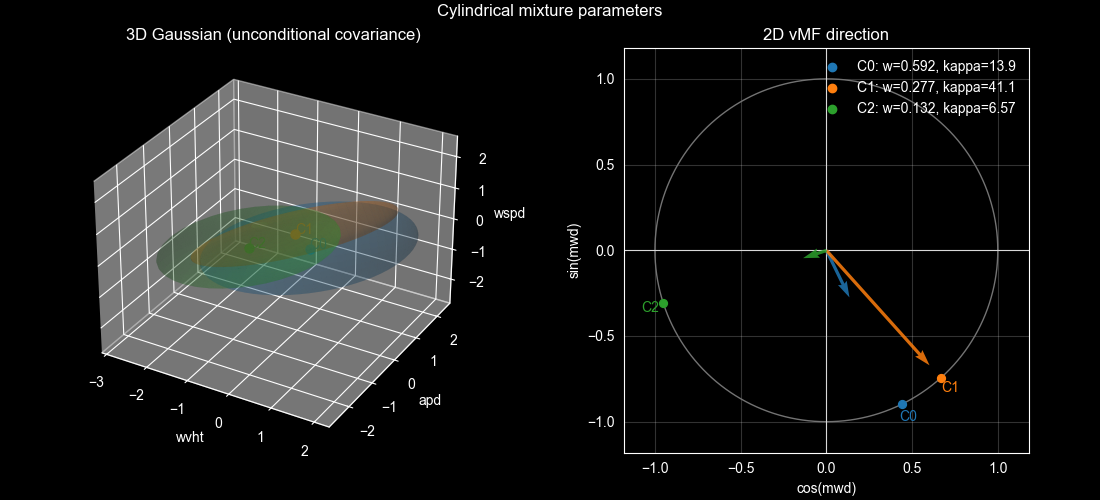

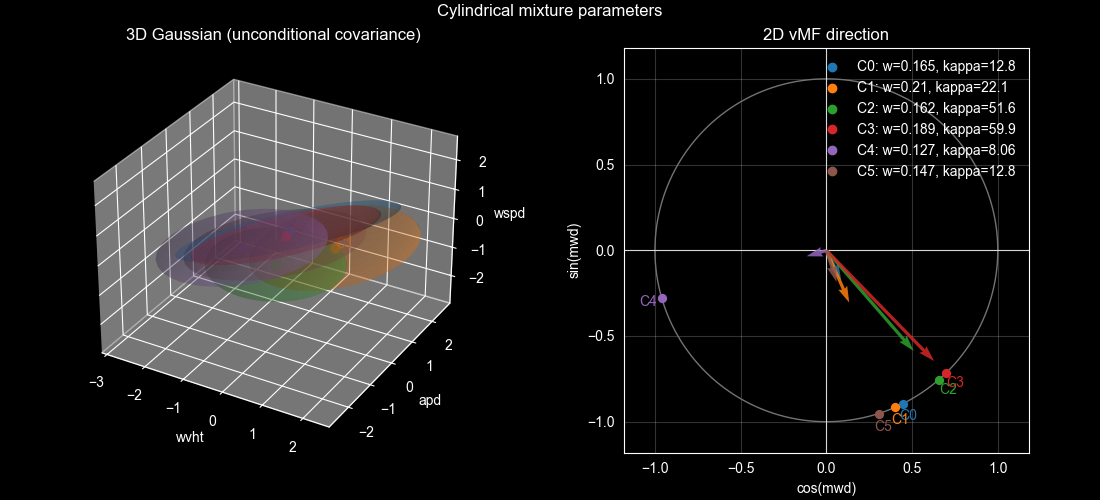

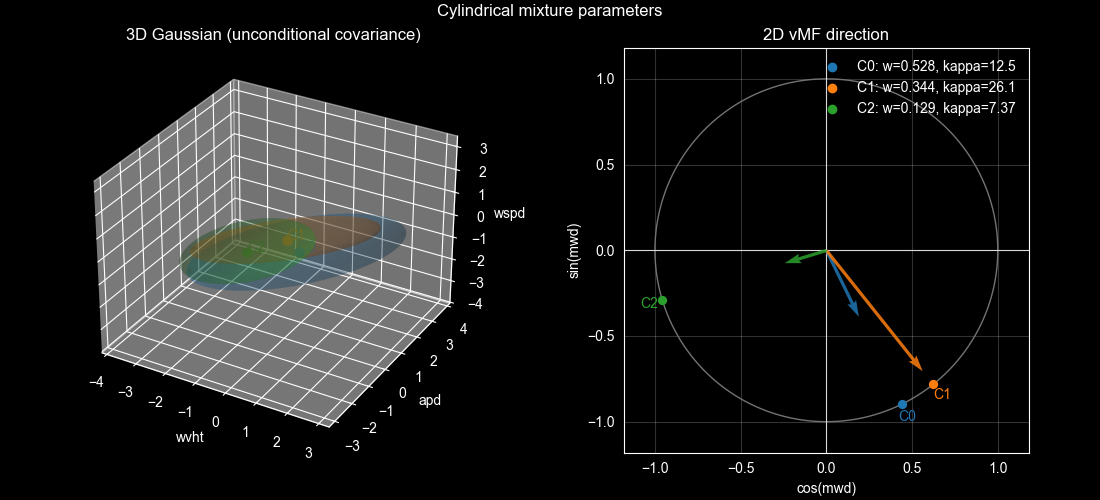

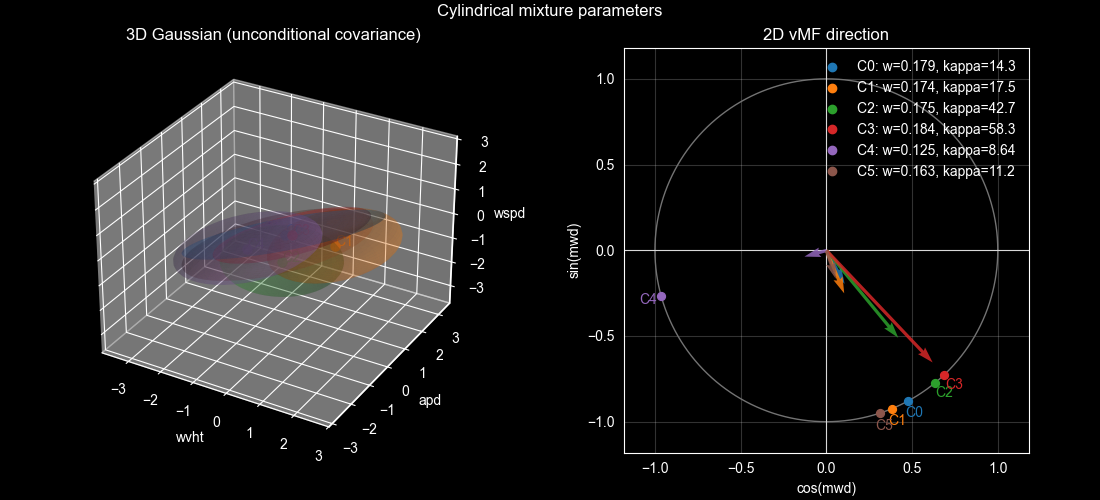

In [14]:
for model in models['cylindrical'].values():
    _ = mod.plot_cylindrical_mixture_parameters(
        model,
        covariance="unconditional",  # or "unconditional" default
        n_std=2.0,
        show=True,
    )

In [15]:
for model in models['cylindrical'].values():
    if hasattr(model, 'cross_cov'):
        fig, axes = mod.plot_cylindrical_cross_covariance_heatmaps(model)

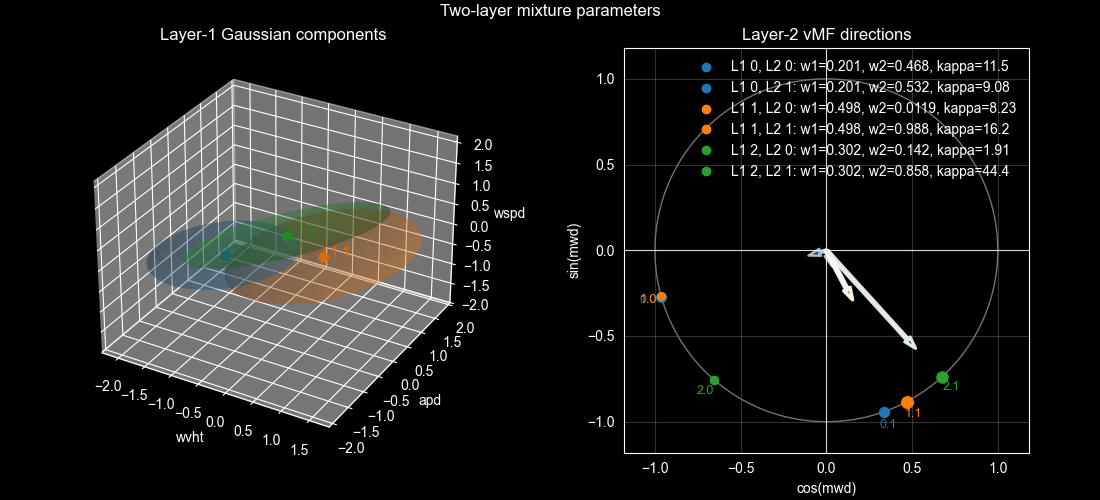

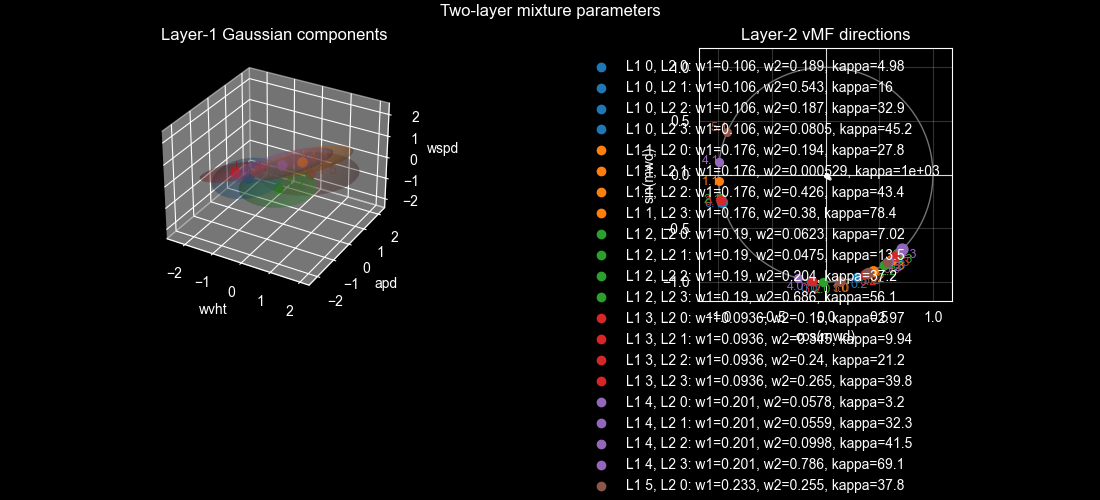

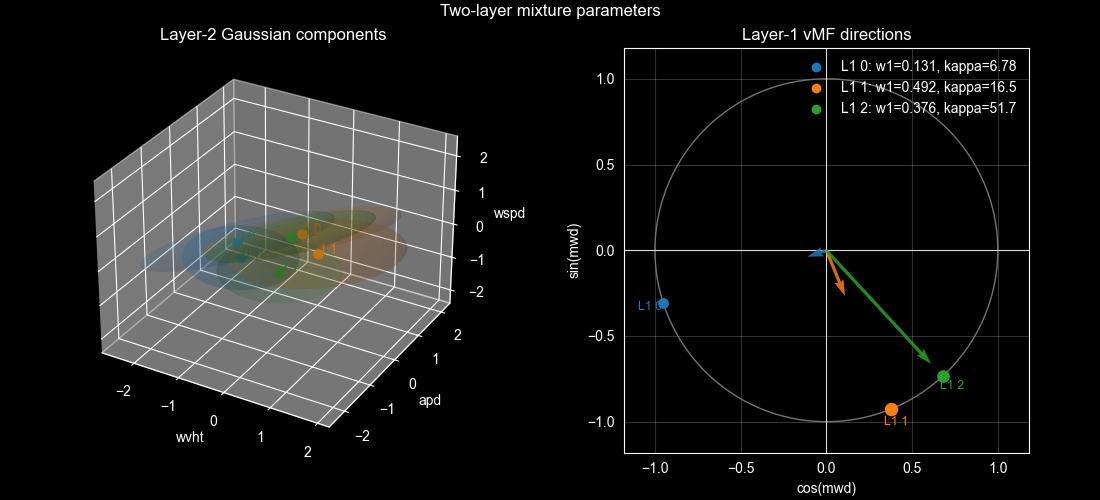

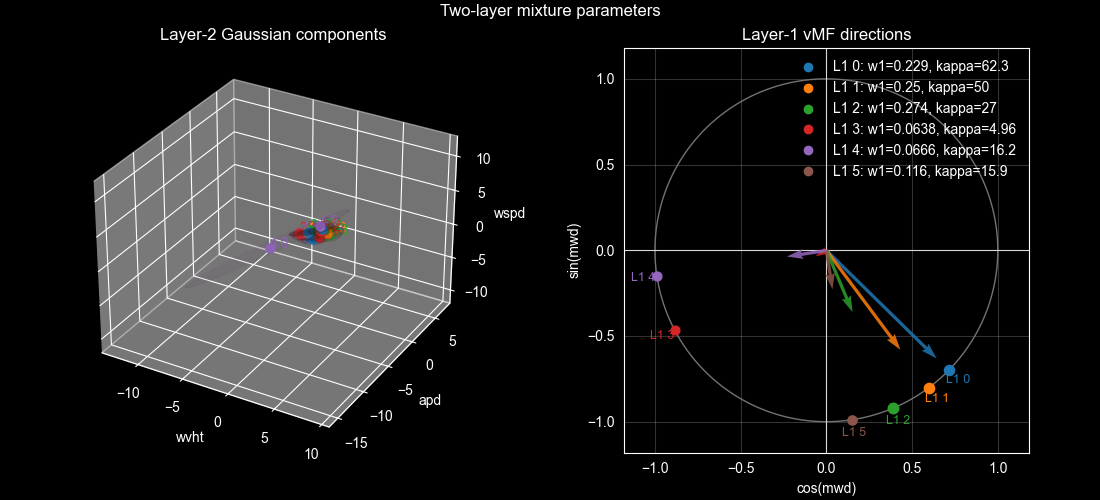

In [16]:
for model in [*models['two-layer-gauss'].values(), *models['two-layer-vmf'].values()]:
    fig, axes = mod.plot_two_layer_mixture_parameters(
        model,
        scale_by_layer2_weight=True,
    )

### Performance

In [17]:
for fam_name, fam_models in models.items():
    for name, model in fam_models.items():
        if fam_name == 'cylindrical':
            hll = model.score(x_test)
        elif fam_name == 'two-layer-gauss':
            hll = model.score(x_test_lin, x_test_dir)
        else:
            hll = model.score(x_test_dir, x_test_lin)

        print(f'{hll:.3f}: {name} Avg. Held-out Log-likelihood')


-3.968: Independent cylindrical Mixture (Elbow) Avg. Held-out Log-likelihood
-3.845: Independent cylindrical Mixture (Grid) Avg. Held-out Log-likelihood
-3.912: Cylindrical Mixture (Elbow) Avg. Held-out Log-likelihood
-3.826: Cylindrical Mixture (Grid) Avg. Held-out Log-likelihood
-3.920: Gaussian/von Mises MoM (Elbow) Avg. Held-out Log-likelihood
-3.784: Gaussian/von Mises MoM (Grid) Avg. Held-out Log-likelihood
-3.822: Von Mises/Gaussian MoM (Elbow) Avg. Held-out Log-likelihood
-3.748: Von Mises/Gaussian MoM (Grid) Avg. Held-out Log-likelihood


In [18]:
rows = []

for fam_name, fam_models in models.items():
    for name, model in fam_models.items():
        if fam_name == 'cylindrical':
            hll = model.score(x_test)
        elif fam_name == 'two-layer-gauss':
            hll = model.score(x_test_lin, x_test_dir)
        elif fam_name == 'two-layer-vmf':
            hll = model.score(x_test_dir, x_test_lin)
        else:
            hll = None

        rows.append({
            "model": name,
            "avg_log_likelihood": hll,
            "K": settings[name][0],
            "L": settings[name][1] if len(settings[name]) > 1 else 0
        })

df = pd.DataFrame(rows)

df

,model,avg_log_likelihood,K,L
0,Independent cylindrical Mixture (Elbow),-3.968259,3,0
1,Independent cylindrical Mixture (Grid),-3.845152,6,0
2,Cylindrical Mixture (Elbow),-3.911542,3,0
3,Cylindrical Mixture (Grid),-3.825528,6,0
4,Gaussian/von Mises MoM (Elbow),-3.920390,3,2
5,Gaussian/von Mises MoM (Grid),-3.784349,6,4
6,Von Mises/Gaussian MoM (Elbow),-3.822081,3,2
7,Von Mises/Gaussian MoM (Grid),-3.747942,6,4


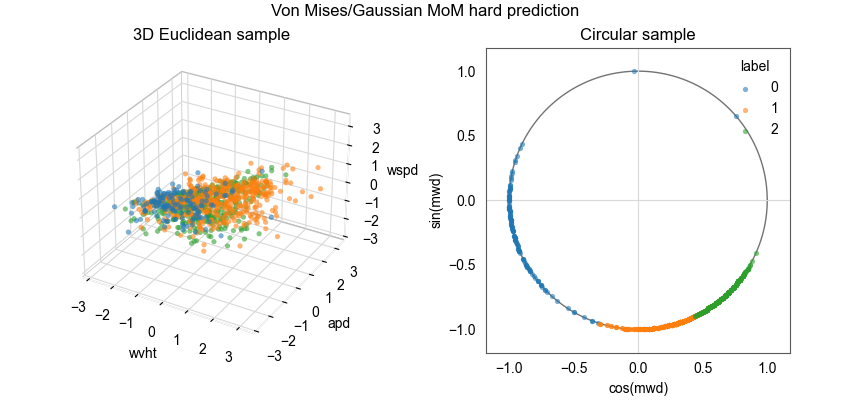

In [35]:
labels = models['two-layer-vmf']['Von Mises/Gaussian MoM (Elbow)'].predict(x_test_dir, x_test_lin)
fig, axes = mod.plot_gaussian_vmf_sample(
    x_test,
    labels=labels,
    max_points=1000,
    figsize=(8.5, 4),
    show=True,
    title="Von Mises/Gaussian MoM hard prediction",
    save_path="noaa_scatter_dir_labeled.pdf"
)

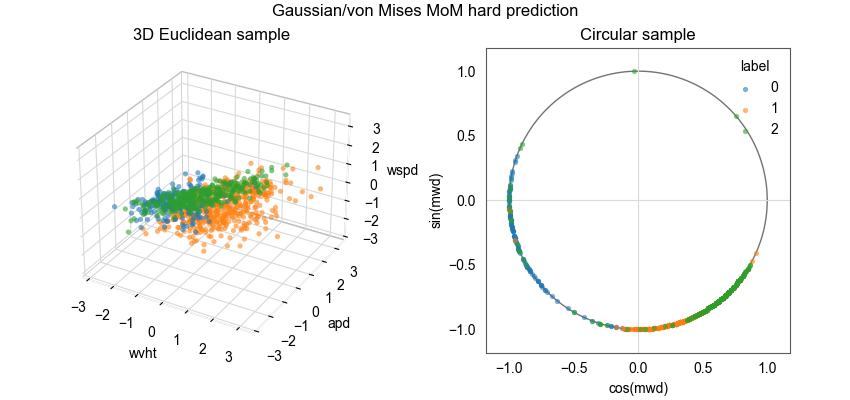

In [43]:
labels = models['two-layer-gauss']['Gaussian/von Mises MoM (Elbow)'].predict(x_test_lin, x_test_dir)
fig, axes = mod.plot_gaussian_vmf_sample(
    x_test,
    labels=labels,
    max_points=1000,
    figsize=(8.5, 4),
    show=True,
    title="Gaussian/von Mises MoM hard prediction",
    save_path="noaa_scatter_lin_labeled.pdf"
)


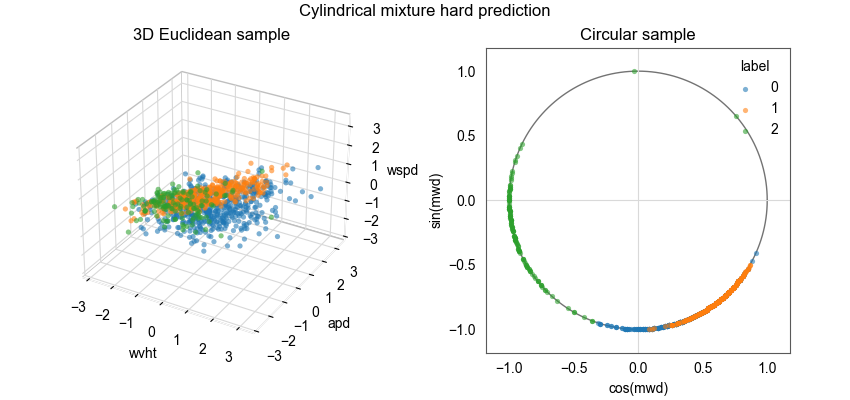

In [44]:
labels = models['cylindrical']['Cylindrical Mixture (Elbow)'].predict(x_test)
fig, axes = mod.plot_gaussian_vmf_sample(
    x_test,
    labels=labels,
    max_points=1000,
    figsize=(8.5, 4),
    show=True,
    title="Cylindrical mixture hard prediction",
    save_path="noaa_scatter_cyl_labeled.pdf"
)